In [2]:
import lemonpy as lp
import numpy as np
import matplotlib.pyplot as plt
import dump_io as io

from astropy import constants as const, units as u
import pickle as pk

from scipy.optimize import curve_fit

In [ ]:
rho_ref = 1e-13

mu = 2.353
T0 = 30 * u.K / mu
v0 = np.sqrt(u.R*T0)
R0 = u.AU.cgs
rho0  = rho_ref * u.g/u.cm**3
t0 = R0 / v0
uM = ud*uL**3


u_aR = (uM*v0**2/(R0**3 * T0**4)).decompose()
aR = ((4*const.sigma_sb/const.c)/u_aR).to_value()


def get_data(kappa=1, rho_ref=1e-12):

    dirc = f'rho{rho_ref:g}/kappa{np.log10(kappa):.1f}/'

    def f(x, a, b, c, d, e): return a * np.sin(b*x+c) * np.exp(d*x) + e
    def fit_eigenvalue(t, x, **kwargs): return curve_fit(f, t, x, **kwargs)[0]

    with open(f'new-rho{rho_ref:g}.pk', 'rb') as file: data = pk.load(file)
    i = lp.tools.where(data['kappa'], kappa)
    t, rho, vx1, prs, Er = np.genfromtxt(f'{dirc}/data_at_x0.dat', unpack=True)
    
    q = Er
    popt = fit_eigenvalue(t, q, p0=[0, 7, np.pi/2, -0.5, 0], maxfev=15000)
    mag, imag, phase, real, off = popt
    
    out = dict(eigenreal=-real, eigenimag=imag,
               eigenreal_exp=data['eigenreal_exp'][i], eigenimag_exp=data['eigenimag_exp'][i])
    return out

kappa         = 10.0 ** np.arange(-2.5, 2.6, 0.5)
eigenreal     = np.zeros_like(kappa)
eigenimag     = np.zeros_like(kappa)

for idx, k in enumerate(kappa):
    try: data = get_data(kappa=k, rho_ref=rho_ref)
    except: data = dict(eigenreal=np.nan, eigenimag=np.nan, eigenreal_exp=np.nan, eigenimag_exp=np.nan)
    eigenreal[idx]     = data['eigenreal']
    eigenimag[idx]     = data['eigenimag']

with open(f'petsc-data_rho{rho_ref:g}.pk', 'rb') as file: data = pk.load(file)
# print(data.keys())
data = dict(kappa=kappa, eigenreal=eigenreal, eigenimag=eigenimag,
            kappa_exp=data['kappa_exp'], eigenreal_exp=data['eigenreal_exp'], eigenimag_exp=data['eigenimag_exp'])
with open(f'idefix-data_rho{rho_ref:g}.pk', 'wb') as f: pk.dump(data, f)

In [5]:
# get_data(kappa=10**0.0, rho_ref=1e-13)

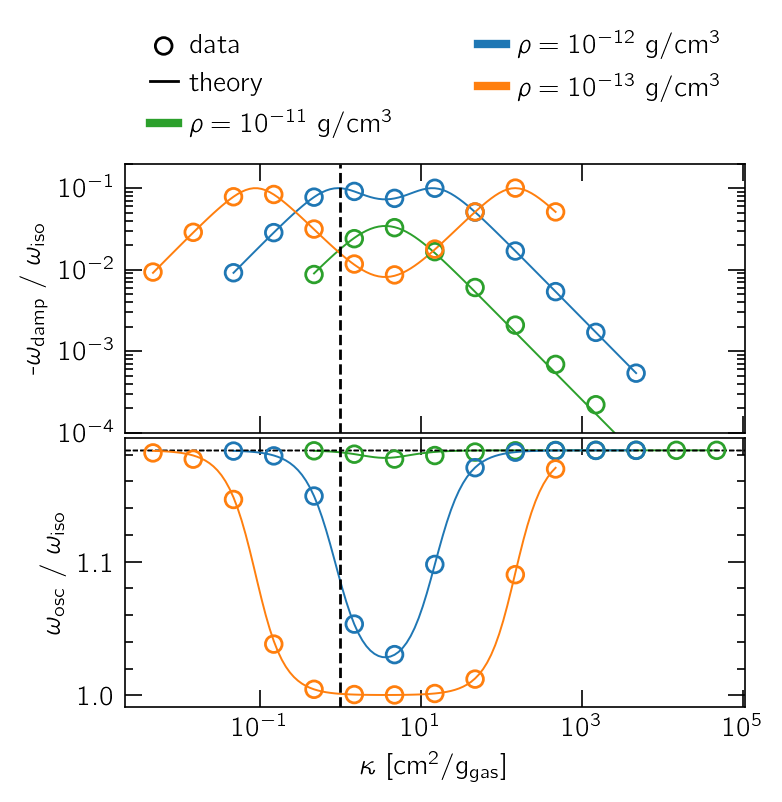

In [6]:
fig, ax = lp.plot.subplots(rows=2, dpi=200, hspace=0.02, rowsize=1.8)

fiso = 2*np.pi
f_time = 2*np.pi

for idx, dirc in enumerate(['rho1e-11', 'rho1e-12', 'rho1e-13']):
    c = {'rho1e-12':'C0', 'rho1e-13':'C1', 'rho1e-11':'C2'}[dirc]

    with open(f'idefix-data_{dirc}.pk', 'rb') as f: data = pk.load(f)
    
    ax[1].axhline(np.sqrt(1.4), ls='--', c='k', lw=0.5)

    f = float(dirc[3:]) * const.au.cgs.value
    ax[0].scatter(data['kappa']*f, data['eigenreal']/fiso, edgecolors=c, facecolors='none', marker='o', zorder=100)
    ax[0].plot(data['kappa_exp']*f, data['eigenreal_exp']/fiso, '-', c=c, lw=0.7)
    ax[1].scatter(data['kappa']*f, data['eigenimag']/fiso, edgecolors=c, facecolors='none', marker='o', zorder=100)
    ax[1].plot(data['kappa_exp']*f, data['eigenimag_exp']/fiso, '-', c=c, lw=0.7)

ax[0].scatter(np.nan, np.nan, label='data', marker='o', facecolors='none', edgecolors='k')
ax[0].plot(np.nan, np.nan, '-', c='k', label='theory')
ax[0].plot(np.nan, np.nan, c='C2', label=r'$\rho=10^{-11}$ g/cm${}^3$')
ax[0].plot(np.nan, np.nan, c='C0', label=r'$\rho=10^{-12}$ g/cm${}^3$')
ax[0].plot(np.nan, np.nan, c='C1', label=r'$\rho=10^{-13}$ g/cm${}^3$')

ax[0].set_ylabel(r'-$\omega_\text{damp}$ / $\omega_\text{iso}$')
ax[1].set_ylabel(r'$\omega_\text{osc}$ / $\omega_\text{iso}$')

lg = ax[0].legend(bbox_to_anchor=[0,1,1,1], loc='lower left', mode='expand', ncol=2, handlelength=1, handletextpad=0.4)
for line in lg.get_lines()[1:]:
    line.set_lw(3)

ax[0].set_ylim(1e-4, 0.2)
for axis in ax: axis.axvline(1, ls='--', c='k')
ax[0].set_yscale('log')

ax[1].set_xlabel(r'$\kappa$ [cm${}^2$/g${}_\text{gas}$]')
for axis in ax: axis.set_xscale('log')
ax[0].set_xticklabels([])

# fig.savefig('../figures/dynamic.pdf', bbox_inches='tight')
plt.show()